<a href="https://colab.research.google.com/github/Sriyansh-36-AI-NITJ/CP-Lab-Endsem/blob/main/Image_Processing_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import subprocess
import urllib.request
import os
import numpy as np
from PIL import Image

# 1. Verify GPU is attached and ready
try:
    print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout)
except FileNotFoundError:
    print("WARNING: nvidia-smi not found. Ensure your notebook has a GPU enabled.")

# 2. Secure a test image safely
test_image_path = "safe_test_image.jpg"
print("Preparing test image...")

try:
    # Use a highly reliable Wikipedia sample image to avoid Berkeley server timeouts
    url = "https://upload.wikimedia.org/wikipedia/commons/thumb/e/e0/JPEG_example_JPG_RIP_025.jpg/512px-JPEG_example_JPG_RIP_025.jpg"
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=10) as response, open(test_image_path, 'wb') as out_file:
        out_file.write(response.read())
    print("Test image secured successfully!")
except Exception as e:
    print(f"Network block detected ({e}). Generating synthetic test data...")
    # Absolute fallback: Generate random colored noise so the pipeline never fails
    synthetic_data = np.random.randint(0, 255, (400, 400, 3), dtype=np.uint8)
    Image.fromarray(synthetic_data).save(test_image_path)
    print("Synthetic test image created.")

Mon Jun  1 06:48:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P0             30W /   70W |     105MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import cupy as cp
from numba import cuda
import math
import matplotlib.pyplot as plt

print("GPU and Math libraries loaded. Ready to compile kernels.")

GPU and Math libraries loaded. Ready to compile kernels.


In [5]:
@cuda.jit
def grayscale_kernel(src, dst):
    x, y = cuda.grid(2)
    height, width, _ = src.shape

    if x < width and y < height:
        r = src[y, x, 0]
        g = src[y, x, 1]
        b = src[y, x, 2]
        dst[y, x] = 0.299 * r + 0.587 * g + 0.114 * b

@cuda.jit
def gaussian_blur_kernel(src, dst):
    x, y = cuda.grid(2)
    height, width = src.shape

    if x < width and y < height:
        pixel_val = 0.0
        weight_sum = 0.0

        for ky in range(-1, 2):
            for kx in range(-1, 2):
                px = x + kx
                py = y + ky

                # Clamp to edge safely
                if px < 0: px = 0
                if px >= width: px = width - 1
                if py < 0: py = 0
                if py >= height: py = height - 1

                if kx == 0 and ky == 0: w = 4.0
                elif kx == 0 or ky == 0: w = 2.0
                else: w = 1.0

                pixel_val += src[py, px] * w
                weight_sum += w

        if weight_sum > 0:
            dst[y, x] = pixel_val / weight_sum
        else:
            dst[y, x] = 0.0

@cuda.jit
def sobel_kernel(src, dst):
    x, y = cuda.grid(2)
    height, width = src.shape

    if x >= 1 and x < (width - 1) and y >= 1 and y < (height - 1):
        gx = (
            -1.0 * src[y-1, x-1] + 1.0 * src[y-1, x+1]
            -2.0 * src[y,   x-1] + 2.0 * src[y,   x+1]
            -1.0 * src[y+1, x-1] + 1.0 * src[y+1, x+1]
        )
        gy = (
            -1.0 * src[y-1, x-1] - 2.0 * src[y-1, x] - 1.0 * src[y-1, x+1]
            +1.0 * src[y+1, x-1] + 2.0 * src[y+1, x] + 1.0 * src[y+1, x+1]
        )

        mag = math.sqrt(gx**2 + gy**2)
        if mag > 255.0: dst[y, x] = 255.0
        else: dst[y, x] = mag

    elif x < width and y < height:
        dst[y, x] = 0.0

print("CUDA Kernels compiled successfully!")

CUDA Kernels compiled successfully!


In [6]:
def process_image_cuda(image_np):
    # Enforce strict 3-channel RGB to prevent memory mismatches
    if len(image_np.shape) != 3 or image_np.shape[2] != 3:
        raise ValueError("Error: Input must be a standard RGB image.")

    height, width, _ = image_np.shape

    # 1. Allocate VRAM cleanly (Float32 is mandatory for Numba/CuPy stability)
    d_src = cp.asarray(image_np, dtype=cp.float32)
    d_gray = cp.zeros((height, width), dtype=cp.float32)
    d_blurred = cp.zeros((height, width), dtype=cp.float32)
    d_edges = cp.zeros((height, width), dtype=cp.float32)

    # 2. Configure Execution Grid
    threads_per_block = (16, 16)
    blocks_per_grid_x = math.ceil(width / threads_per_block[0])
    blocks_per_grid_y = math.ceil(height / threads_per_block[1])
    blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)

    # 3. Execute with forced synchronization
    grayscale_kernel[blocks_per_grid, threads_per_block](d_src, d_gray)
    cuda.synchronize()

    gaussian_blur_kernel[blocks_per_grid, threads_per_block](d_gray, d_blurred)
    cuda.synchronize()

    sobel_kernel[blocks_per_grid, threads_per_block](d_blurred, d_edges)
    cuda.synchronize()

    # 4. Bring the data back to CPU RAM safely
    return cp.asnumpy(d_edges).astype(np.uint8)

print("Memory orchestrator ready.")

Memory orchestrator ready.


Pushing data to GPU and executing pipeline...
Pipeline execution complete! Rendering results...


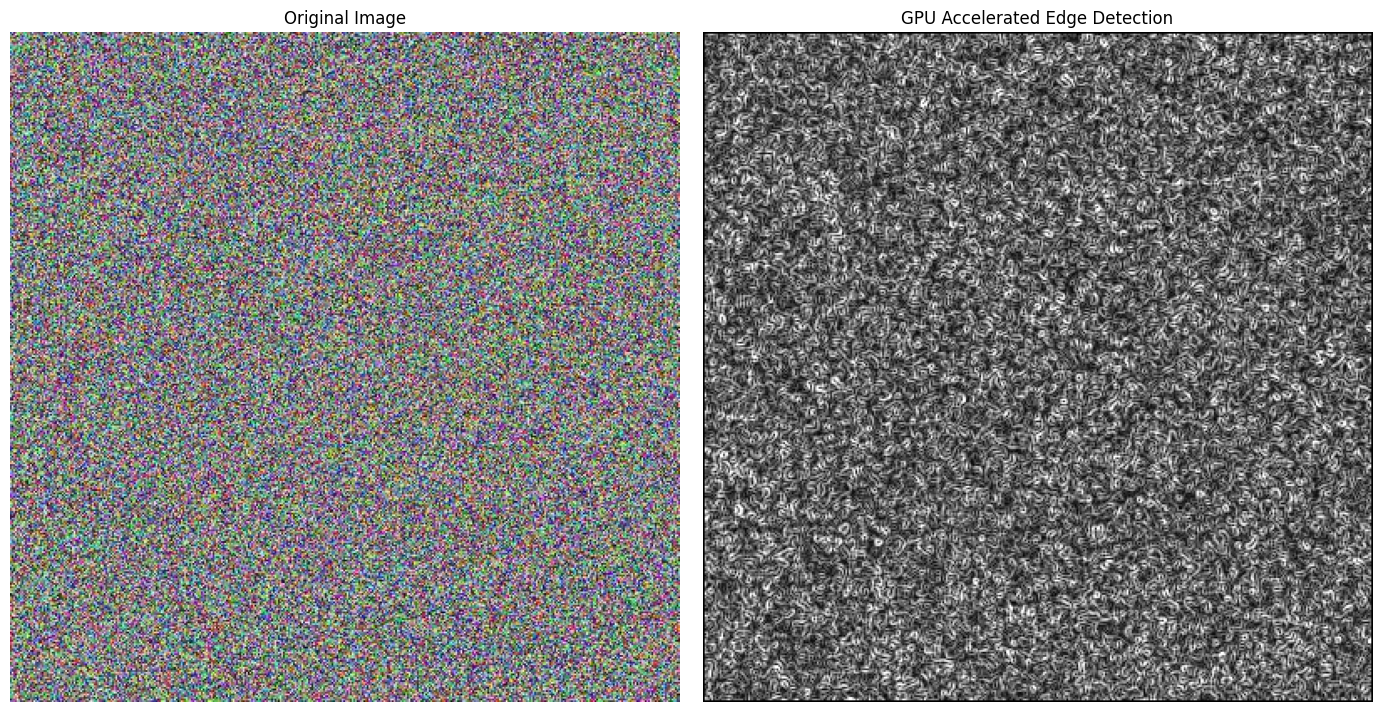

In [7]:
# 1. Load the image we secured in Cell 1
img = Image.open("safe_test_image.jpg").convert('RGB')
img_array = np.array(img)

print("Pushing data to GPU and executing pipeline...")

# 2. Process
edge_result = process_image_cuda(img_array)
print("Pipeline execution complete! Rendering results...")

# 3. Visualize
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

ax[0].imshow(img)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(edge_result, cmap="gray")
ax[1].set_title("GPU Accelerated Edge Detection")
ax[1].axis("off")

plt.tight_layout()
plt.show()